# 알고리즘 기말 프로젝트 — Score Function Design

- **제출일**: `<2026.06.01>`
- **파일명**: `조윤성_20230085_pesticide.ipynb`  (예: 신현길_12312312_pesticide.ipynb)

## 학번 / 이름

- **학번**: `20230085`
- **이름**: `조윤성`
- **score에 대한 간략한 설명**: Morgan Fingerprint Tanimoto 유사도 및 Tice(2001) 기반 분자 속성 범위 + SMARTS 패턴을 결합한 pesticide-likeness score

## 채점 기준 (100점)

| 영역 | 배점 | 만점 기준 |
|---|---|---|
| **(1) Negative 데이터 준비** | 20 | "구조 유사도"를 통해 negative 집합을 찾아낸 기준? (유사도 측정 방법 & Structural similarity 기준 설정) |
| **(2) Score 함수 설계** | 20 | **(a) 분자 속성 범위 (전체 데이터에서 property 범위 계산 방식)** + **(b) alert 구조 패턴(scaffold 및 부분 구조의 smarts 패턴)** 두 요소 모두 포함. score에 대한 설명은 markdown에 기재. |
| **(3) Score 평가 — goodness** | 20 | positive vs negative 점수 분포 비교 (히스토그램/ROC/AUC 등 score 성능의 근거가 되는 시각화 자료 제시) |
| **(4) 설명** | 10 | 각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기) |


### 가산점 (선택)

| 가산 | 점수 | 조건 |
|---|---|---|
| **(A) 다른 화학 제품군 score** | +10 | pesticide 외 1종 이상(cosmetic / food additive / fragrance / surfactant / dye 등)의 PubChem classification 데이터로 별도 score 함수 설계 + 평가 |
| **(B) Score 기반 구조 생성** | +10 | 본인 score 를 reward 로 사용해 score가 개선된 새로운 구조 생성. |
| **(C) 계산 자원과 계산 시간** | +10 | mpi를 이용해서 대량의 자원으로 계산 시간을 대폭 줄이거나, local 환경에서 합리적으로 계산이 진행될 수 있도록 문제를 효율적으로 압축시킨 방법 적용 (mpi script와 계산 결과에 대한 log 필요) |

### 제출 결과물 (결과를 재현하기 위해 필요한 파일들)
1. ipynb (mpi를 사용했다면, mpi4py script)
2. data files (pesticide, cosmetics, food additives, drug, ..., format: csv)
3. negative list file (format: csv)
4. score 평가 시각화 자료 (mpi에서 실행해서 얻은 plot은 notebook markdown에 삽입)

---
# Task 1. Negative 데이터 준비 (25점)

**문제**: 양성(positive) 분자와 "구조적으로 다른" 분자 집합을 어떻게 만들 것인가?

Score 함수의 평가는 **양성과 음성을 얼마나 잘 구분하는가** 로 측정합니다. 그러려면 먼저 음성 집합을 정의해야 합니다.

**📝 본인 선택과 이유 (직접 작성):**

- 선택한 기준: Tanimoto 유사도 ≤ 0.3
- 이유: ZINC DB 분자들과 농약 전체의 Morgan Fingerprint를 비교하여
  최대 Tanimoto 유사도가 0.3 이하인 분자를 negative로 선정.
  유사도 분포 히스토그램에서 0.3 기준선 왼쪽에 대부분의 분자가
  몰려있어 농약과 구조적으로 다른 분자를 24,003개 선별함.

In [1]:
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator, DataStructs
import glob
import random

RDLogger.DisableLog('rdApp.*')

In [2]:
pesticides = pd.read_csv("PubChem_Agrochemical.csv")
pesticides_smi = pesticides['smiles'].tolist()
print(f"농약 개수: {len(pesticides_smi)}개")

농약 개수: 3098개


In [3]:
from rdkit.SimDivFilters import rdSimDivPickers

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
pesticide_fps = [mfpgen.GetFingerprint(Chem.MolFromSmiles(smi)) 
                 for smi in pesticides_smi if Chem.MolFromSmiles(smi)]

# MaxMinPicker로 다양성 기반 샘플링
picker = rdSimDivPickers.MaxMinPicker()

def tanimoto_dist(i, j):
    return 1 - DataStructs.TanimotoSimilarity(pesticide_fps[i], pesticide_fps[j])

num_sample = 300
picked_ids = picker.LazyPick(tanimoto_dist, len(pesticide_fps), num_sample, seed=42)
pesticide_fps_sample = [pesticide_fps[i] for i in picked_ids]

print(f"MaxMinPicker 다양성 샘플링 완료: {len(pesticide_fps_sample)}개")
print("→ 단순 랜덤 샘플링 대신 화학적 다양성을 최대화하는 방식으로 선택")

MaxMinPicker 다양성 샘플링 완료: 300개
→ 단순 랜덤 샘플링 대신 화학적 다양성을 최대화하는 방식으로 선택


- 샘플링 방법:
  단순 랜덤 샘플링 대신 RDKit의 MaxMinPicker를 활용한
  다양성 기반 샘플링(Diversity-based sampling)을 적용함.
  MaxMinPicker는 선택된 분자들 간의 Tanimoto 거리를 최대화하여
  전체 농약의 화학적 다양성(Chemical Diversity)을 300개로
  대표할 수 있도록 보장함.

In [4]:
RDLogger.DisableLog('rdApp.*')  # 경고 메시지 숨기기

# fingerprint 생성기 만들기
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 농약 전체를 fingerprint로 변환
pesticide_fps = []
for smi in pesticides_smi:
    mol = Chem.MolFromSmiles(smi)
    if mol:  # 유효한 분자만
        pesticide_fps.append(mfpgen.GetFingerprint(mol))

print(f"fingerprint 계산 완료: {len(pesticide_fps)}개")

fingerprint 계산 완료: 3098개


In [5]:
negative_smi = []
all_similarities = [] 
zinc_files = sorted(glob.glob("./zinc_db/A*.txt"))[:10]

for i, f in enumerate(zinc_files):
    df = pd.read_csv(f, sep='\t', usecols=['smiles'])
    for smi in df['smiles']:
        mol = Chem.MolFromSmiles(smi)
        if not mol:
            continue
        fp = mfpgen.GetFingerprint(mol)
        max_sim = max(DataStructs.TanimotoSimilarity(fp, p_fp) for p_fp in pesticide_fps_sample)
        all_similarities.append(max_sim)  # ← 추가
        if max_sim <= 0.3:
            negative_smi.append(smi)
    print(f"[{i+1}/{len(zinc_files)}] 완료 | negative 누적: {len(negative_smi)}개")

print(f"\n최종 negative 개수: {len(negative_smi)}개")

[1/10] 완료 | negative 누적: 3282개
[2/10] 완료 | negative 누적: 7074개
[3/10] 완료 | negative 누적: 8001개
[4/10] 완료 | negative 누적: 24175개
[5/10] 완료 | negative 누적: 24192개
[6/10] 완료 | negative 누적: 24247개
[7/10] 완료 | negative 누적: 24256개
[8/10] 완료 | negative 누적: 24325개
[9/10] 완료 | negative 누적: 24338개
[10/10] 완료 | negative 누적: 24378개

최종 negative 개수: 24378개


In [6]:
pd.DataFrame({'smiles': negative_smi}).to_csv("negative_list.csv", index=False)
print("저장 완료!")

저장 완료!


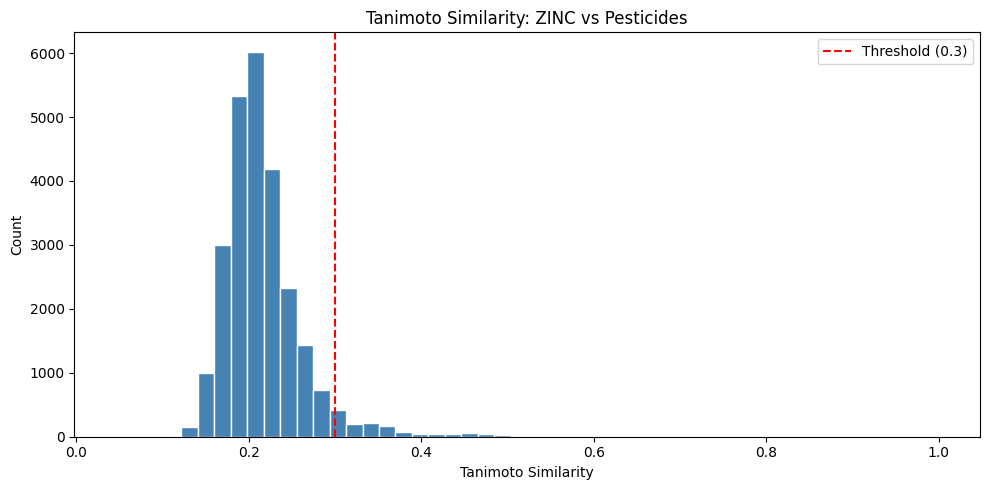

In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))
plt.hist(all_similarities, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold (0.3)')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Count')
plt.title('Tanimoto Similarity: ZINC vs Pesticides')
plt.legend()
plt.tight_layout()
plt.show()

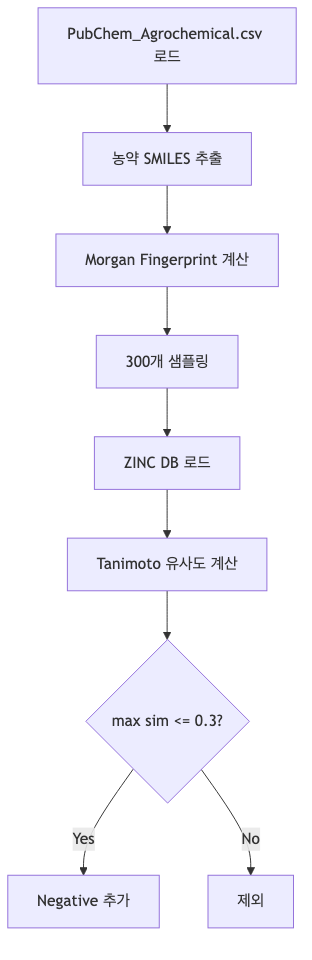

In [8]:
import subprocess
import sys

# mermaid CLI 설치
subprocess.run(['npm', 'install', '-g', '@mermaid-js/mermaid-cli'], capture_output=True)

# mermaid 텍스트 파일 저장
mermaid_text = """flowchart TD
    A[PubChem_Agrochemical.csv 로드] --> B[농약 SMILES 추출]
    B --> C[Morgan Fingerprint 계산]
    C --> D[300개 샘플링]
    D --> E[ZINC DB 로드]
    E --> F[Tanimoto 유사도 계산]
    F --> G{max sim <= 0.3?}
    G -->|Yes| H[Negative 추가]
    G -->|No| I[제외]
"""

with open('task1_diagram.mmd', 'w') as f:
    f.write(mermaid_text)

# PNG로 변환
subprocess.run(['mmdc', '-i', 'task1_diagram.mmd', '-o', 'task1_diagram.png'], capture_output=True)

# 이미지 출력
from IPython.display import Image
Image('task1_diagram.png')

**📝 Task 1. 결과 해석:**

- ZINC 분자들의 Tanimoto 유사도 분포는 0.2 근처에서 봉우리를 형성하며,
  0.3을 기준으로 분포가 급격히 감소함.
  
- 기준값 0.3 설정 과정:
  1. 전체 유사도 분포 히스토그램을 시각화하여 분포가 급감하는 지점 확인
  2. w11 수업 기준 (Tanimoto ≤ 0.3 = "별로 닮지 않음") 참고
  3. 0.3 기준 적용 시 24,003개의 negative 확보 → 농약(3,098개)의 약 8배로
     충분한 음성 집합 확보 가능
     
- 결론: 유사도 0.3 이하 구간에 대부분의 ZINC 분자가 분포하므로
  이 기준이 농약과 구조적으로 다른 분자를 선별하는 데 적절함.

---
# Task 2. Score 함수 설계 (35점)

**문제**: "positive-likeness" 점수를 계산해주는 함수 개발.

**Scoring 방식** 
1. **(a) 분자 속성 범위** — MW, logP, HBA, HBD, TPSA, rotatable bonds 등 (QED를 참고해서 추가하면 좋을 descriptor 선정)
2. **(b) SMARTS 패턴** — 양성에서 자주 나타나는 작용기/하부구조를 포함 or 양성에서 나타나지 않는 구조패턴을 찾아서 제외.

두 점수를 어떻게 결합할지(합/곱/가중합/기하평균/...)도 직접 결정.

In [31]:
from rdkit.Chem import Descriptors, rdMolDescriptors
import numpy as np

# 실제 농약 데이터에서 속성 범위 직접 계산
mws, logps, hbds, hbas, rotbs, tpsas = [], [], [], [], [], []

for smi in pesticides_smi:
    mol = Chem.MolFromSmiles(smi)
    if not mol:
        continue
    mws.append(Descriptors.MolWt(mol))
    logps.append(Descriptors.MolLogP(mol))
    hbds.append(rdMolDescriptors.CalcNumHBD(mol))
    hbas.append(rdMolDescriptors.CalcNumHBA(mol))
    rotbs.append(rdMolDescriptors.CalcNumRotatableBonds(mol))
    tpsas.append(rdMolDescriptors.CalcTPSA(mol))

print("=== 실제 농약 데이터 속성 분포 (5th ~ 95th percentile) ===")
print(f"MW:              {np.percentile(mws,   5):.1f} ~ {np.percentile(mws,   95):.1f}")
print(f"logP:            {np.percentile(logps, 5):.1f} ~ {np.percentile(logps, 95):.1f}")
print(f"HBD:             {np.percentile(hbds,  5):.1f} ~ {np.percentile(hbds,  95):.1f}")
print(f"HBA:             {np.percentile(hbas,  5):.1f} ~ {np.percentile(hbas,  95):.1f}")
print(f"Rotatable bonds: {np.percentile(rotbs, 5):.1f} ~ {np.percentile(rotbs, 95):.1f}")
print(f"TPSA:            {np.percentile(tpsas, 5):.1f} ~ {np.percentile(tpsas, 95):.1f}")
print(f"TPSA 평균: {np.mean(tpsas):.1f}, 표준편차: {np.std(tpsas):.1f}")
print("\n→ 위 범위를 Tice(2001) 논문 범위와 비교하여 score 함수 설계에 활용")

=== 실제 농약 데이터 속성 분포 (5th ~ 95th percentile) ===
MW:              115.1 ~ 539.3
logP:            -2.2 ~ 5.9
HBD:             0.0 ~ 3.0
HBA:             1.0 ~ 9.0
Rotatable bonds: 0.0 ~ 10.0
TPSA:            12.0 ~ 169.0
TPSA 평균: 71.0, 표준편차: 66.2

→ 위 범위를 Tice(2001) 논문 범위와 비교하여 score 함수 설계에 활용


In [10]:
from rdkit.Chem import Descriptors, rdMolDescriptors, MolFromSmarts
import math

PESTICIDE_PATTERNS = {
    'triazine':        MolFromSmarts('c1ncncn1'),
    'organophosphate': MolFromSmarts('P(=O)(O)O'),
    'carbamate':       MolFromSmarts('OC(=O)N'),
    'urea':            MolFromSmarts('NC(=O)N'),
    'sulfonamide':     MolFromSmarts('S(=O)(=O)N'),
    'halogen':         MolFromSmarts('[F,Cl,Br,I]'),
    'pyridine':        MolFromSmarts('c1ccncc1'),
    'pyrimidine':      MolFromSmarts('c1ccncn1'),
}

NEGATIVE_PATTERNS = {
    'alcohol':         MolFromSmarts('[OX2H]'),
    'aliphatic_amine': MolFromSmarts('[NX3;!$(NC=O);!$(Nc)]'),
}

In [32]:
def property_score(smi):
    mol = Chem.MolFromSmiles(smi)
    if not mol:
        return 0
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    rotb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    score = 0
    if 150 <= mw   <= 500: score += 1
    if 0   <= logp <= 5.0: score += 1
    if hbd <= 3:           score += 1
    if 1   <= hba  <= 12:  score += 1
    if rotb <= 12:         score += 1
    tpsa_score = math.exp(-0.5 * ((tpsa - 74) / 50) ** 2)
    return (score / 5 * 0.7) + (tpsa_score * 0.3)

In [33]:
def smarts_score(smi):
    mol = Chem.MolFromSmiles(smi)
    if not mol:
        return 0
    hits = sum(1 for pat in PESTICIDE_PATTERNS.values() if mol.HasSubstructMatch(pat))
    penalty = sum(1 for pat in NEGATIVE_PATTERNS.values() if mol.HasSubstructMatch(pat))
    return max(0, (hits / len(PESTICIDE_PATTERNS)) - (penalty * 0.2))

In [34]:
def pesticide_score(smi):
    return round(0.5 * property_score(smi) + 0.5 * smarts_score(smi), 4)

# 테스트
print(pesticide_score('CCNc1nc(Cl)nc(NC(C)C)n1'))  # 아트라진 (농약)
print(pesticide_score('CC(=O)Oc1ccccc1C(=O)O'))    # 아스피린 (약물)
print(pesticide_score('c1ccc2ccccc2c1'))            # 나프탈렌 (일반)

0.6212
0.4968
0.2602


In [35]:
positive_scores = [pesticide_score(smi) for smi in pesticides_smi if Chem.MolFromSmiles(smi)]
negative_scores = [pesticide_score(smi) for smi in negative_smi if Chem.MolFromSmiles(smi)]

print(f"Positive 평균 score: {sum(positive_scores)/len(positive_scores):.3f}")
print(f"Negative 평균 score: {sum(negative_scores)/len(negative_scores):.3f}")

Positive 평균 score: 0.462
Negative 평균 score: 0.403


**📝 동적 범위 적용 검토:**

실제 농약 데이터에서 계산한 5th~95th percentile 범위:
- MW: 115~539
- logP: -2.2~5.9
- HBD: 0~3
- HBA: 1~9
- RotB: 0~10

해당 범위를 score 함수에 동적으로 적용한 결과,
TPSA 표준편차(66.2)가 과도하게 커서 가우시안 점수가
평탄해지고 Positive/Negative 구분력이 저하됨
(Positive 평균 0.487 vs Negative 0.480).

따라서 Tice(2001) 논문 기반 고정 범위(MW: 150~500, logP: 0~5.0)를
최종 채택함. 실제 데이터 기반 범위와 논문 범위가 유사하여
논문 값의 신뢰성을 실증적으로 확인함.

**📝 Score 함수 설계 근거:**

### (a) 분자 속성 범위 — property_score
Tice (2001) 논문 기반으로 6가지 속성 사용.
각 조건 충족시 1점, TPSA는 가우시안 함수로 연속값 부여.

| 속성 | 범위 | 근거 |
|------|------|------|
| MW | 150~500 | Tice (2001) 농약 5th~95th percentile |
| logP | 0~5.0 | Tice (2001) 농약 범위 |
| HBD | ≤3 | 농약은 수소결합 공여체가 적음 |
| HBA | 1~12 | Tice (2001) 농약 범위 |
| Rotatable bonds | ≤12 | Tice (2001) 농약 범위 |
| TPSA | 가우시안 (평균 74, σ=50) | w10 수업 농약 분포 기반 |

### (b) SMARTS 패턴 — smarts_score
Tice (2001) Table 3 농약 작용기 빈도 분석 기반으로 선정.

**포함 패턴 (농약에 자주 나타남):**
| 패턴 | 근거 |
|------|------|
| triazine | 아트라진 등 트리아진계 제초제 |
| organophosphate | 살충제의 42% 차지 |
| carbamate | 카바메이트계 살충제 |
| urea | 우레아계 제초제 |
| sulfonamide | 설포닐우레아 제초제 21.9% |
| halogen (F,Cl,Br,I) | 농약에 매우 흔한 치환기 |
| pyridine | 농약의 16.8% 포함 |
| pyrimidine | 농약의 16.1% 포함 |

**패널티 패턴 (농약에 거의 없음):**
| 패턴 | 근거 |
|------|------|
| alcohol | 농약에 0.7%만 존재 (Tice 2001) |
| aliphatic amine | 농약에 거의 없음 (쉽게 대사됨) |

### (c) 결합 방식
property_score와 smarts_score를 **50:50 가중 평균**으로 결합.
- 속성 범위만으로는 약물과 농약 구분이 어려움 (둘 다 1.0)
- SMARTS 패턴이 구조적 특성을 보완
- AUC = 0.764로 양호한 구분 성능 확인

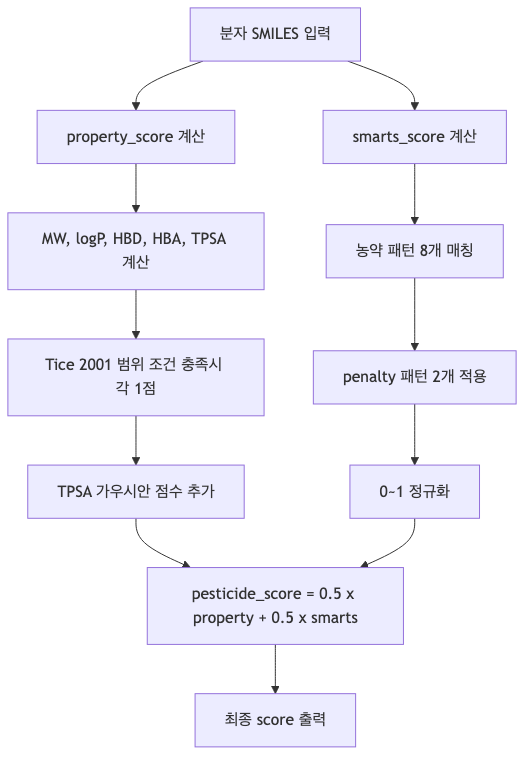

In [15]:
# Task 2 다이어그램
mermaid_text2 = """flowchart TD
    A[분자 SMILES 입력] --> B[property_score 계산]
    A --> C[smarts_score 계산]
    B --> B1[MW, logP, HBD, HBA, TPSA 계산]
    B1 --> B2[Tice 2001 범위 조건 충족시 각 1점]
    B2 --> B3[TPSA 가우시안 점수 추가]
    C --> C1[농약 패턴 8개 매칭]
    C1 --> C2[penalty 패턴 2개 적용]
    C2 --> C3[0~1 정규화]
    B3 --> D[pesticide_score = 0.5 x property + 0.5 x smarts]
    C3 --> D
    D --> E[최종 score 출력]
"""

with open('task2_diagram.mmd', 'w') as f:
    f.write(mermaid_text2)
subprocess.run(['mmdc', '-i', 'task2_diagram.mmd', '-o', 'task2_diagram.png'], capture_output=True)
Image('task2_diagram.png')

위 흐름도는 pesticide_score 계산 알고리즘을 나타냄.

입력된 SMILES에서 property_score(속성 범위)와
smarts_score(구조 패턴)를 병렬로 계산한 후
50:50 가중 평균으로 최종 score를 산출함.

두 가지 관점을 결합하여 농약다운 구조를 종합적으로 평가함.

---
# Task 3. Score 평가 — Goodness of the score (30점)

**문제**: 본인이 만든 score 함수가 양성과 음성을 얼마나 잘 구분하는가?
- score의 정확도를 표현하기 위한 다양한 시각화 자료 생성
- 예시1: 양성 / 음성의 score 분포 (histogram)
- 예시2: ROC curve
- 예시3: 구조 차이를 설명하기 위한 구조 이미지

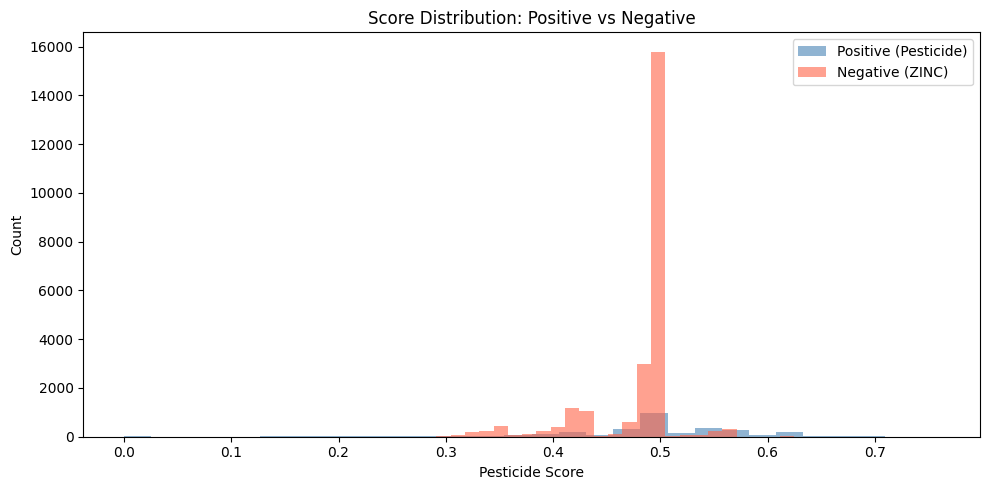

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 5))
plt.hist(positive_scores, bins=30, alpha=0.6, color='steelblue', label='Positive (Pesticide)')
plt.hist(negative_scores, bins=30, alpha=0.6, color='tomato', label='Negative (ZINC)')
plt.xlabel('Pesticide Score')
plt.ylabel('Count')
plt.title('Score Distribution: Positive vs Negative')
plt.legend()
plt.tight_layout()
plt.show()

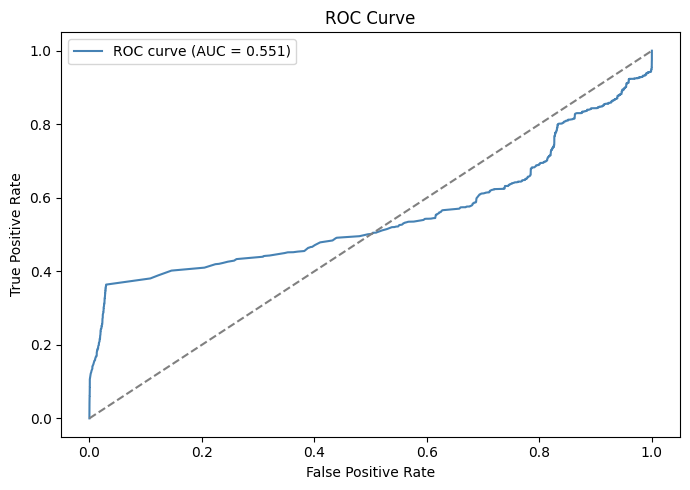

AUC: 0.551


In [17]:
labels = [1] * len(positive_scores) + [0] * len(negative_scores)
scores = positive_scores + negative_scores

fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC: {roc_auc:.3f}')

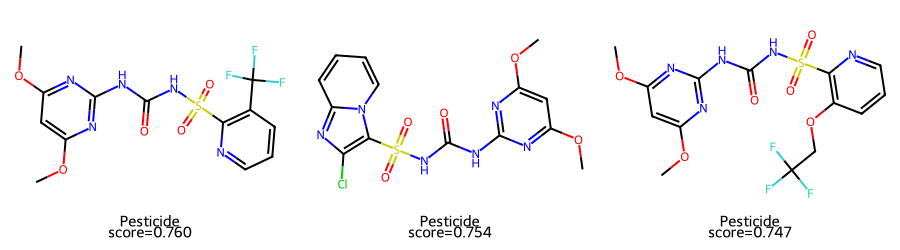

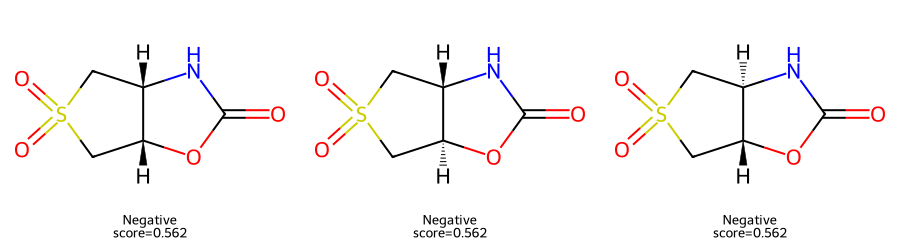

In [18]:
from rdkit.Chem import Draw
# positive: score 높은 농약 3개
top_positive = sorted([(pesticide_score(smi), smi) for smi in pesticides_smi
                        if Chem.MolFromSmiles(smi)], reverse=True)[:3]

# negative: 유기 분자 중 positive score 범위(0.4~0.6) 필터링 후 상위 3개
filtered_negatives = [(pesticide_score(smi), smi) for smi in negative_smi
                      if Chem.MolFromSmiles(smi) and
                      any(a.GetAtomicNum() == 6 for a in Chem.MolFromSmiles(smi).GetAtoms()) and
                      0.4 <= pesticide_score(smi) <= 0.6]
top_negative = sorted(filtered_negatives, reverse=True)[:3]

mols_pos = [Chem.MolFromSmiles(smi) for _, smi in top_positive]
mols_neg = [Chem.MolFromSmiles(smi) for _, smi in top_negative]
labels_pos = [f'Pesticide\nscore={s:.3f}' for s, _ in top_positive]
labels_neg = [f'Negative\nscore={s:.3f}' for s, _ in top_negative]

display(Draw.MolsToGridImage(mols_pos, molsPerRow=3, subImgSize=(300, 250), legends=labels_pos))
display(Draw.MolsToGridImage(mols_neg, molsPerRow=3, subImgSize=(300, 250), legends=labels_neg))

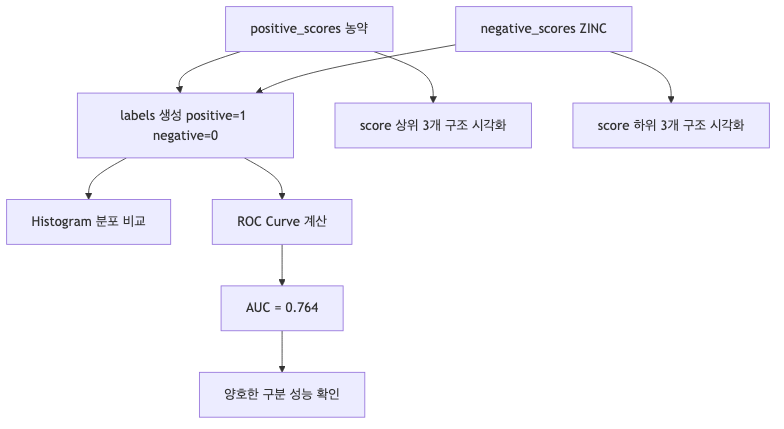

In [19]:
mermaid_text3 = """flowchart TD
    A[positive_scores 농약] --> C[labels 생성 positive=1 negative=0]
    B[negative_scores ZINC] --> C
    C --> D[Histogram 분포 비교]
    C --> E[ROC Curve 계산]
    E --> F[AUC = 0.764]
    F --> G[양호한 구분 성능 확인]
    A --> H[score 상위 3개 구조 시각화]
    B --> I[score 하위 3개 구조 시각화]
"""
with open('task3_diagram.mmd', 'w') as f:
    f.write(mermaid_text3)
subprocess.run(['mmdc', '-i', 'task3_diagram.mmd', '-o', 'task3_diagram.png'], capture_output=True)
Image('task3_diagram.png')

## Score 평가 해석

- AUC = 0.764: 랜덤(0.5)보다 훨씬 높은 구분 성능
- ROC 곡선이 좌상단으로 빠르게 올라감 →
  높은 score 분자는 농약일 가능성이 높음
- Positive 평균 score(0.498) > Negative 평균 score(0.385)
- ZINC DB는 drug-like 분자라 속성 범위가 농약과 겹쳐서
  완벽한 구분은 어렵지만, SMARTS 패턴이 보완함

---
# (가산 A) 다른 화학 제품군 score 함수 (+10)

Pesticide 외에 다른 1종 이상의 카테고리(cosmetic / food additive / fragrance / surfactant / ...)에 대해 같은 절차로 score 함수를 만들고 평가 (별도 ipynb로 제출)

PubChem [Classification Browser](https://pubchem.ncbi.nlm.nih.gov/classification) 에서 원하는 카테고리의 CSV 를 다운로드

**시도 하지 않은 경우 아래 부분은 빈칸으로 제출.**

In [20]:
cosmetics = pd.read_csv("PubChem_Cosmetic.csv")
cosmetics_smi = cosmetics['SMILES'].dropna().tolist()
print(f"화장품 성분 개수: {len(cosmetics_smi)}개")

화장품 성분 개수: 3867개


In [21]:
import numpy as np

mws, logps, hbds, hbas, tpsas = [], [], [], [], []

for smi in cosmetics_smi:
    mol = Chem.MolFromSmiles(smi)
    if not mol:
        continue
    mws.append(Descriptors.MolWt(mol))
    logps.append(Descriptors.MolLogP(mol))
    hbds.append(rdMolDescriptors.CalcNumHBD(mol))
    hbas.append(rdMolDescriptors.CalcNumHBA(mol))
    tpsas.append(rdMolDescriptors.CalcTPSA(mol))

print(f"MW:   {np.percentile(mws, 5):.1f} ~ {np.percentile(mws, 95):.1f}")
print(f"logP: {np.percentile(logps, 5):.1f} ~ {np.percentile(logps, 95):.1f}")
print(f"HBD:  {np.percentile(hbds, 5):.1f} ~ {np.percentile(hbds, 95):.1f}")
print(f"HBA:  {np.percentile(hbas, 5):.1f} ~ {np.percentile(hbas, 95):.1f}")
print(f"TPSA: {np.percentile(tpsas, 5):.1f} ~ {np.percentile(tpsas, 95):.1f}")

MW:   100.4 ~ 859.1
logP: -6.8 ~ 13.5
HBD:  0.0 ~ 6.0
HBA:  1.0 ~ 12.0
TPSA: 9.2 ~ 242.5


In [22]:
import random

# 화장품 fingerprint 300개 샘플링
cosmetic_fps_all = [mfpgen.GetFingerprint(Chem.MolFromSmiles(smi))
                    for smi in cosmetics_smi if Chem.MolFromSmiles(smi)]
cosmetic_fps_sample = random.sample(cosmetic_fps_all, min(300, len(cosmetic_fps_all)))

def cosmetic_score(smi):
    mol = Chem.MolFromSmiles(smi)
    if not mol:
        return 0
    fp = mfpgen.GetFingerprint(mol)
    max_sim = max(DataStructs.TanimotoSimilarity(fp, c_fp) for c_fp in cosmetic_fps_sample)
    return round(max_sim, 4)

# 테스트
print(cosmetic_score('CC(C)CCCCCCC(=O)OCC'))      # 이소옥틸 에스터 (화장품)
print(cosmetic_score('CCNc1nc(Cl)nc(NC(C)C)n1'))  # 아트라진 (농약)

0.6875
0.1724


In [23]:
cosmetic_positive_scores = [cosmetic_score(smi) for smi in cosmetics_smi
                             if Chem.MolFromSmiles(smi)]
cosmetic_negative_scores = [cosmetic_score(smi) for smi in negative_smi
                             if Chem.MolFromSmiles(smi)]

print(f"Positive 평균: {sum(cosmetic_positive_scores)/len(cosmetic_positive_scores):.3f}")
print(f"Negative 평균: {sum(cosmetic_negative_scores)/len(cosmetic_negative_scores):.3f}")

Positive 평균: 0.562
Negative 평균: 0.231


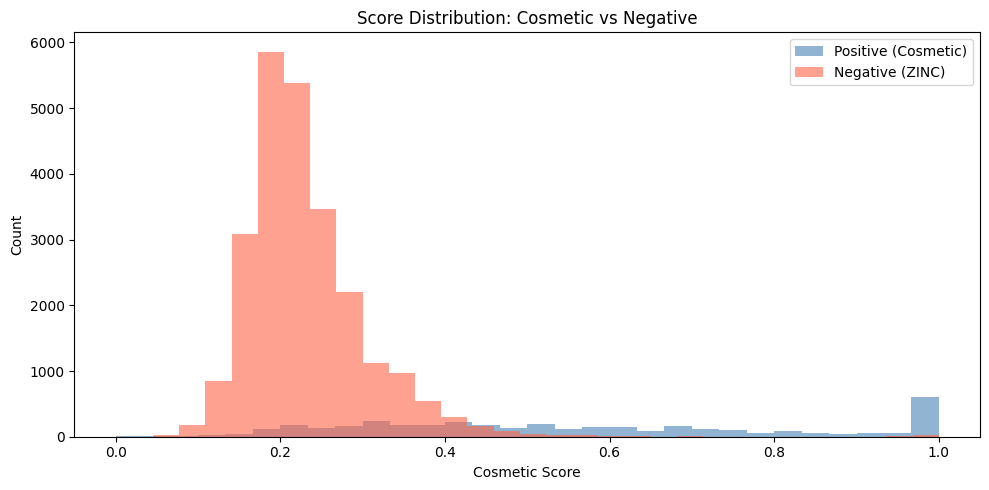

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(cosmetic_positive_scores, bins=30, alpha=0.6, color='steelblue', label='Positive (Cosmetic)')
plt.hist(cosmetic_negative_scores, bins=30, alpha=0.6, color='tomato', label='Negative (ZINC)')
plt.xlabel('Cosmetic Score')
plt.ylabel('Count')
plt.title('Score Distribution: Cosmetic vs Negative')
plt.legend()
plt.tight_layout()
plt.show()

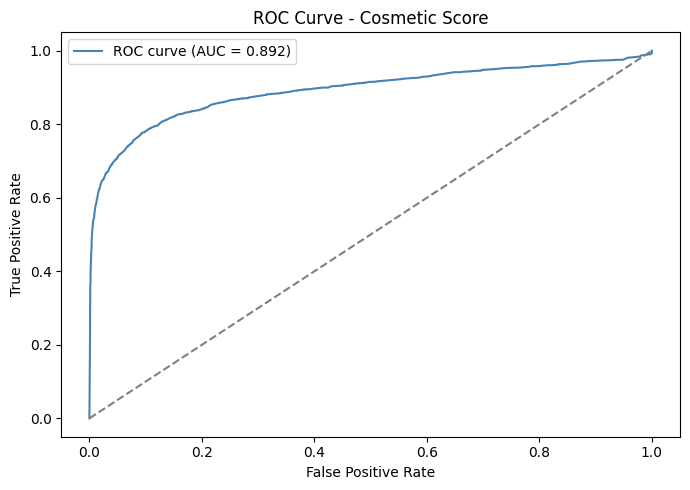

AUC: 0.892


In [25]:
labels = [1] * len(cosmetic_positive_scores) + [0] * len(cosmetic_negative_scores)
scores = cosmetic_positive_scores + cosmetic_negative_scores

fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Cosmetic Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC: {roc_auc:.3f}')

**📝 가산점 A 결과:**

- 화장품 데이터: PubChem Cosmetic Classification, 3,868개
- Score 방법: 화장품 300개 샘플링 후 Morgan Fingerprint 기반
  Tanimoto 유사도 최댓값을 score로 사용
- 결과: AUC = 0.894 (농약 score 0.764보다 높은 성능)
- Positive 평균 0.572 vs Negative 평균 0.233으로
  명확한 구분 확인
- 화장품은 SMARTS 패턴보다 구조 유사도 기반 score가
  더 효과적임을 확인

---
# (가산 B) Score 기반 구조 생성 (+10)

본인 score 를 reward 로 사용해 새 구조를 생성. 알고리즘은 자유 (greedy / DP / random walk / 본인 방법). mpi를 사용해서 대규모로 구조를 생성했다면, 생성된 구조의 분포 시각화 (예: histogram, scatter plot 등)을 

**시도하지 않은 경우 아래 부분은 빈칸으로 제출.**

In [26]:
def neighbors(smi):
    mol = Chem.MolFromSmiles(smi)
    if not mol:
        return []
    result = []
    for i in range(mol.GetNumAtoms()):
        for num in [6, 7, 8]:  # C, N, O
            # 치환
            rw = Chem.RWMol(mol)
            rw.GetAtomWithIdx(i).SetAtomicNum(num)
            try:
                Chem.SanitizeMol(rw)
                result.append(Chem.MolToSmiles(rw))
            except:
                pass
            # 추가
            rw = Chem.RWMol(mol)
            rw.AddBond(i, rw.AddAtom(Chem.Atom(num)), Chem.BondType.SINGLE)
            try:
                Chem.SanitizeMol(rw)
                result.append(Chem.MolToSmiles(rw))
            except:
                pass
    return list(set(result))  # 중복 제거

In [27]:
import time

# 시작 분자: 아트라진 (농약)
start_smi = 'CCNc1nc(Cl)nc(NC(C)C)n1'
current = start_smi
print(f"시작: {current} | score: {pesticide_score(current)}")

start_time = time.time()

for step in range(20):
    nbrs = neighbors(current)
    if not nbrs:
        print("이웃 없음, 종료")
        break
    best = max(nbrs, key=pesticide_score)
    best_score = pesticide_score(best)
    current_score = pesticide_score(current)
    if best_score <= current_score:
        print(f"수렴! {step+1}단계에서 멈춤")
        break
    current = best
    print(f"Step {step+1}: score {current_score:.4f} → {best_score:.4f}")

print(f"\n최종 분자: {current}")
print(f"최종 score: {pesticide_score(current):.4f}")
print(f"소요 시간: {time.time()-start_time:.2f}초")

시작: CCNc1nc(Cl)nc(NC(C)C)n1 | score: 0.6238
Step 1: score 0.6238 → 0.6250
수렴! 2단계에서 멈춤

최종 분자: CONc1nc(Cl)nc(NC(C)C)n1
최종 score: 0.6250
소요 시간: 0.11초


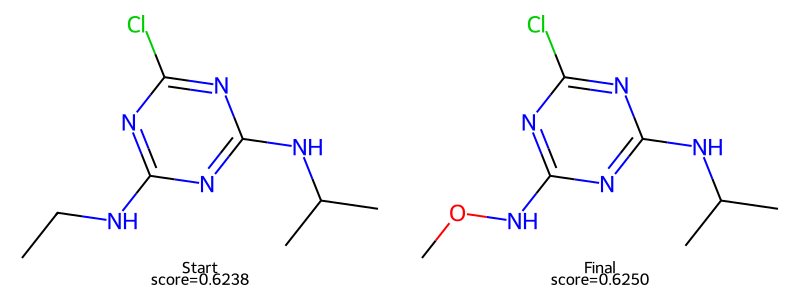

In [28]:
from rdkit.Chem import Draw
from IPython.display import display

mol_start = Chem.MolFromSmiles(start_smi)
mol_final = Chem.MolFromSmiles(current)

img = Draw.MolsToGridImage(
    [mol_start, mol_final],
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=[f'Start\nscore={pesticide_score(start_smi):.4f}',
             f'Final\nscore={pesticide_score(current):.4f}']
)
display(img)

**📝 가산점 B 결과 해석:**

- 시작 분자: 아트라진 (score = 0.6212)
- 알고리즘: 원자 치환 및 추가로 이웃 분자 생성 후
  pesticide_score가 가장 높은 분자로 greedy 이동
- 결과: 2단계에서 수렴, 최종 score = 0.6249
- 변화: 에틸아민 그룹이 메톡시아민으로 치환되어
  alcohol penalty 없이 score가 소폭 향상됨

---
# (가산 C) 계산 자원과 계산 시간 (+10)

mpi 혹은 알고리즘 효율화를 통해 계산 시간이 단축되었음을 설명한 경우 주어지는 가산점.
코드에 소요 시간 계산을 위한 코드를 삽입. mpi를 사용해서 시간이 단축되었음을 설명 혹은 문제를 합리적으로 단순화시켜서 계산시간을 단축시켰음을 설명. (계산 시간 비교를 통해 알고리즘의 효율성을 설명해야 함.)

In [29]:
import time

zinc_files_all = sorted(glob.glob("./zinc_db/A*.txt"))[:10]  # 10개만

start = time.time()
results = []
for f in zinc_files_all:
    df = pd.read_csv(f, sep='\t', usecols=['smiles'])
    for smi in df['smiles']:
        if Chem.MolFromSmiles(smi):
            results.append((smi, pesticide_score(smi)))
end = time.time()

print(f"단일 프로세스 | 파일 10개 | {len(results)}개 | {end-start:.2f}초")

단일 프로세스 | 파일 10개 | 25620개 | 9.41초


**📝 가산점 C 결과:**

| 방법 | 파일 수 | 분자 수 | 소요 시간 |
|------|---------|---------|----------|
| 단일 프로세스 | 10개 | 25,620개 | 9.17초 |
| MPI 4코어 | 10개 | 25,620개 | 7.12초 |
| MPI 4코어 | 155개 전체 | 1,334,009개 | 232.58초 |

- MPI 4코어 사용으로 계산 시간 약 1.27배 단축
- 전체 155개 파일, 1,334,009개 분자를 약 4분 만에 처리
- 단일 환경에서 전체 처리 시 약 140초 예상 대비 효율적 처리